In [1]:
import pandas as pd
import numpy as np
import h5py
import os
import matplotlib.pyplot as plt
#from gwpy.timeseries import TimeSeries
from matplotlib.ticker import ScalarFormatter
import seaborn as sns
from matplotlib.gridspec import GridSpec
import numpy as np
from sklearn.decomposition import PCA
from matplotlib.colors import LinearSegmentedColormap
import time
import matplotlib.ticker as ticker
import warnings
import sys
sys.path.insert(0, './utils')
from utils.measure import Measure, Binning, CoincMass, SNRveto
from utils.plot import Plotting as pl
from utils import utilities as ut
from utils.utilities import CountProperTime
from read import DataProcessor, Merge, LogitToStat, PrepareZeroLag
warnings.filterwarnings('ignore')
%matplotlib inline

plt.rcParams['figure.figsize'] = [8, 6]
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['legend.fontsize'] = 15
plt.rcParams['xtick.labelsize'] = 15
plt.rcParams['ytick.labelsize'] = 15
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['figure.dpi'] = 100

plt.style.use("seaborn-colorblind")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

In [ ]:
H1 = pd.read_csv('pred_unknown_H1.csv')
L1 = pd.read_csv('pred_unknown_L1.csv')
V1 = pd.read_csv('pred_unknown_V1.csv')
H1, L1, V1 = reduceData(H1), reduceData(L1), reduceData(V1)

In [ ]:
tw = 0.5
sigmaM1, sigmaM2 = 3, 3
var = H1.iloc[0]
tmp = L1

In [ ]:
harmonics = list()

for i in range(10000):
    var = H1.iloc[i]
    tmp = L1
    tmp = tmp.loc[(tmp['Mass_1'] - sigmaM1 < var['Mass_1']) & (tmp['Mass_1'] + sigmaM1 > var['Mass_1'])]
    tmp = tmp.loc[(tmp['Mass_2'] - sigmaM2 < var['Mass_2']) & (tmp['Mass_2'] + sigmaM2 > var['Mass_2'])]
    coincident = tmp.loc[(tmp['Cluster time'] < var['Cluster time'] + tw) & (tmp['Cluster time'] > var['Cluster time'] + tw)]

    if len(coincident) > 0:
        print(coincident)
    harmonic = 2/(1/tmp['Prob0'] + 1/var['Prob0'])
    harmonics.extend(harmonic.values)
seconds_in_year = 365 * 24 * 60 * 60
print('We have '+str(len(harmonics)*0.05/seconds_in_year)+' years of data')

In [ ]:
val = 0.99998109
path = '/data/gravwav/lopezm/Projects/GlitchBank/time_slides/'
ifo = 'H1L1V1'

seconds_in_year = 365 * 24 * 60 * 60
total_size = 0
larger_size = 0
i =0
for file in os.listdir(path):
    if '_' + ifo + '_' in file:

        if i == 0:
            weights = getWeights(tmp, window=0.01)
        else: 
            weights = np.vstack([weights, getWeights(tmp, window=0.01)])
        tmp = np.load(path + file, allow_pickle=True)
        count = np.sum(tmp > val)
        if count > 0:
            larger_elements = tmp[tmp > val]
        total_size = total_size + len(tmp)
        larger_size = larger_size + count
        print(larger_size/total_size * 100,
              str(np.round(total_size*0.05/seconds_in_year,2))+' years of data', weights.shape)
        i = i +1

In [ ]:
grid = np.arange(0, 1, 0.01)
print(grid.shape, np.sum(weights, axis=0).shape)
# Calculate the total sum of frequencies
total_sum = sum(np.sum(weights, axis=0))

# Normalize the frequencies
normalized_weights = np.sum(weights, axis=0) / total_sum

# Plot histogram from frequency table
plt.bar(grid, np.sum(weights, axis=0), width=0.01)


In [ ]:
plt.bar(grid, np.sum(weights, axis=0), width=0.01)

plt.axvline(grid[np.where(np.cumsum(vec) /vec.sum() > 0.8413)[0][0]], c='crimson')
plt.axvline(grid[np.where(np.cumsum(vec) /vec.sum() > 0.9772)[0][0]], c='crimson')
plt.xlim(0.8, 1.0)

In [ ]:
vec =  np.sum(weights, axis=0)
plt.plot(grid, np.cumsum(vec) /vec.sum())
plt.xlabel('Probability $P_{inj}$')
plt.ylabel('Probability of occurrence')
plt.axhline(0.847, c='cornflowerblue', label=r'$\sigma$')
plt.axhline(0.9772, c='darkorange', label=r'$2\sigma$')
plt.axhline(0.9987, c='mediumseagreen', label=r'$3\sigma$')
plt.legend()

In [ ]:
vec = np.sum(weights, axis=0)
vec.sum() * 0.5 < vec

In [ ]:
vals = [0.99998109, 0.99998109]
path = '/data/gravwav/lopezm/Projects/GlitchBank/time_slides/'
ifo = 'H1L1V1'

seconds_in_year = 365 * 24 * 60 * 60
total_size = 0
larger_size = 0
i =0
matrix = np.empty(len(vals))
for file in os.listdir(path):
    if '_' + ifo + '_' in file:

        tmp = np.load(path + file, allow_pickle=True)
        for j, val in enumerate(vals):
            count = np.sum(tmp > val)
            if count > 0:
                larger_elements = tmp[tmp > val]
            total_size = total_size + len(tmp)
            larger_size = larger_size + count
            fpr = larger_size/total_size
            analysis_time = np.round(total_size*0.05/seconds_in_year,2)
            fap = (larger_size/total_size)/analysis_time
            matrix[j] = fap
            print(fpr, str(analysis_time)+' years of data, FAR = ', fap)
        i = i +1

In [ ]:
ifo = 'H1L1V1'
path_files = '/data/gravwav/lopezm/Projects/GlitchBank/time_slides/datasets/'
vals, cats, names, rhos = list(), list(), list(), list()
for files in ['reducedGWOSC.csv','reduced'+ifo+'.csv',
              'reducedNitz.csv','reducedPrinceton.csv']:

    df = pd.read_csv(path_files + files)

    if files != 'reducedH1L1V1.csv':
        df = df[df['I'] == ifo]
        catalog = files.replace('reduced', "").replace('.csv', "")
        cat = np.full(len(df), catalog)
        probs = df['P\_inj']
        names.extend(df['Name'].values)
        rhos.extend(df['rho'].values)
    else:
        cat = np.full(len(df), 'New')
        probs = df['AvProb0']
        names.extend(df['MaxGPStime_H1'].values.astype(int))
        rhos.extend(df['AvSNR'].values)

    vals.extend(probs.values)
    cats.extend(cat)
path= '/data/gravwav/lopezm/Projects/GlitchBank/time_slides/'
seconds_in_year = 365 * 24 * 60 * 60
total_size = 0

i =0
matrix = np.zeros(len(vals), dtype=int)
for file in os.listdir(path):
    if '_' + ifo + '_' in file:
        try:
            tmp = np.load(path + file, allow_pickle=True)
            total_size = total_size + len(tmp)

            for j, val in enumerate(vals):
                count = int(np.sum(tmp >= val))
                if count > 0:
                    matrix[j] = matrix[j] + count
        except OSError as e:
            # Some files can be corrupted but it is OK!
            # We have more than enough background
            print(e)
            pass
        

        i = i +1
analysis_time = np.round(total_size*0.05/seconds_in_year,2)
far = (matrix)/analysis_time
percentage = (matrix/total_size)*100
analysis_time = np.ones(len(far)) * analysis_time
results = pd.DataFrame({'Name': names, 'Catalog': cats,
                        'P\_inj': vals, 'NetSNR': rhos,
                        'FAR': far, 'Percentage': percentage,
                          'Analysis_time': analysis_time})
#results.to_csv(file.split('.')[0]+'_FAR.csv')

### Who let the dogs out

We create the data set without dogs

In [ ]:
def getData(types,  ifo, tw=0.05, run=None):
    tw = str(tw)
    if types == 'unknown':
        path = '../../unknown_data/' # path to unknown data 
        dt = pd.read_csv(path + 'times_unknown_'+ifo+'_'+tw+'.csv')
        df = pd.read_csv(path + 'features_unknown_'+ifo+'_'+tw+'.csv')
        # Accidentaly swapped these columns when storing
        dt[['Cluster ID', 'Cluster time']] = dt[['Cluster time', 'Cluster ID']]
    if types == 'known':
        path = '../../new_boostrapped/tw'+tw+'/' # path to known data
        dt = pd.DataFrame(np.load(path + 'dataset_all_' + ifo+'_bootstrap_'+run+'_IDs.npy'),
                          columns = ['Cluster ID', 'Cluster time'])
        df = pd.DataFrame(np.load(path + 'dataset_all_'+ ifo+'_bootstrap_'+run+'.npy'))
    return dt, df

def getDogsOut(times, dt, df, types, tw, ifo, run=None):
        idxs =  list()
        for i in range(len(times)):
            t_star = times[i]

            tmp = dt.loc[(dt['Cluster time'] >= t_star - w) & (dt['Cluster time'] <= t_star + w)]
            if len(tmp) > 0:
                idxs.extend(tmp.index.values)
                #print(t_star, len(tmp), catalog['commonName'][i], tmp.index.values)
        # Time and features without dogs
        dt_ = dt.drop(idxs)
        df_ = df.drop(idxs)
        
        if types == 'known':
            path = '../../new_boostrapped/tw'+tw+'/'
            name = 'dataset_nodogs_all_' + ifo+'_bootstrap_'+run+'.npy'
            namet = 'dataset_nodogs_all_' + ifo+'_bootstrap_'+run+'_IDs.npy'
            dt_, df_ = dt_.to_numpy(), df_.to_numpy()
            np.save(path + namet, dt_)
            np.save(path + name, df_)
        if types == 'unknown':
            path = '../../unknown_data/'
            name = 'features_nodogs_unknown_'+ifo+'_'+tw+'.csv'
            namet = 'times_nodogs_unknown_'+ifo+'_'+tw+'.csv'
            dt_.to_csv(path + namet)
            df_.to_csv(path + name)


In [ ]:
path = '/data/gravwav/lopezm/Projects/GlitchBank/computational-aspects-of-machine-learning-project-3/plotsPaper/'
file = 'little_dogs.csv'

In [ ]:
times = pd.read_csv(path + file)['GPS']

In [ ]:
tw, w = str(0.05), 5

for types in ['known', 'unknown']:
    for ifo in ['H1', 'L1', 'V1']:

        if types == 'known':
            for run in ['O3a', 'O3b']:
                dt, df = getData(types,  ifo, run=run) 
                getDogsOut(times, dt, df, types, tw, ifo, run=run)
        else:
            dt, df = getData(types, ifo) 
            getDogsOut(times, dt, df, types, tw, ifo)

In [ ]:
tmp1 = pd.read_csv('/data/gravwav/lopezm/Projects/GlitchBank/computational-aspects-of-machine-learning-project-3/output_new/tw0.05/predictions/pred_nodogs_unknown_H1.csv')
tmp2 = pd.read_csv('/data/gravwav/lopezm/Projects/GlitchBank/computational-aspects-of-machine-learning-project-3/output_new/tw0.05/predictions/pred_nodogs_unknown_L1.csv')

In [ ]:
len(tmp1) - len(tmp2)

In [ ]:
IDs = np.arange(0, 2100, 20)
print(len(IDs))
for ifos in ['HL', 'HV', 'LV', 'HLV']:
    for ID in IDs:
        if os.path.exists(path_store + 'triggers'+ifos+'_run'+str(ID)+'.csv'):
            pass
        else:
            print('triggersHL_run'+str(ID)+'.csv')


In [ ]:
zero_lag = pd.read_csv('../output_new/tw0.05/predictions/pred_unknown_H1L1V1.csv')
len(np.unique(zero_lag['Prob0_H1']))/ len(zero_lag['Prob0_H1'])

In [ ]:
ID = 0
ifos = 'HLV'
tmp = pd.read_csv(path_store + 'triggers'+ifos+'_run'+str(ID)+'.csv')
print(len(np.unique(tmp['Pinj_H1'])), len(tmp['Pinj_H1']))

ID = 22
tmp_ = pd.read_csv(path_store + 'triggers'+ifos+'_run'+str(ID)+'.csv')
np.unique(tmp['Pinj_H1']) == np.unique(tmp_['Pinj_H1'])
plt.hist(tmp['Pinj_H1'], bins=25)
plt.hist(tmp_['Pinj_H1'], bins=25)

In [ ]:
!ls /data/gravwav/lopezm/Projects/GlitchBank/runs/background/results/triggersHL_run0.csv | head -10

### Preliminary plotting

In [3]:
# def returnFAR(tmp, allcatalogs, x_obs, FAR_obs, ifo, far=0.01, offset=0.1):
#     for i in range(len(allcatalogs)):
        
#         cond1 = tmp['Cluster_time_'+ifo[:1]] >= allcatalogs['GPS'].iloc[i] - offset
#         cond2 = tmp['Cluster_time_'+ifo[:1]] <= allcatalogs['GPS'].iloc[i] + offset
#         dt = tmp[(cond1) & (cond2)]
        
#         if len(dt) > 0:
#             ranking =  dt['barPinj'].values[0]
#             allcatalogs['FAR_'+ifo].iloc[i], _ = Measure.stat2FAR(ranking, x_obs, FAR_obs) #FIXME
#             print(ranking, allcatalogs['FAR_'+ifo].iloc[i])
#     return allcatalogs
def returnFAR(allcatalogs, x_obs, FAR_obs, ifo, far=0.01, offset=0.1):
    for i in range(len(allcatalogs)):
        ranking = allcatalogs['RS_'+ifo].iloc[i]
        allcatalogs['FAR_'+ifo].iloc[i], _ = Measure.stat2FAR(ranking, x_obs, FAR_obs) #FIXME
    return allcatalogs

In [4]:
#Some parameters
t_search = 0.5 # FIXME
sigma12, sigma22 = 3, 3 # sigma of mass1 for 2coinc, sigma of mass2 for 2coinc
sigma13, sigma23 = 10, 10 # sigma of mass1 for 3coinc, sigma of mass2 for 3coinc
path_store = '/data/gravwav/lopezm/Projects/GlitchBank/runs/background/results/'
timeslides_file = 'timeslides_1132.9y.csv'
merge = Merge(path_store, timeslides_file)
allcatalogs = pd.read_pickle('/data/gravwav/lopezm/Projects/GlitchBank/runs/known_catalogs.csv')
I = ['H1L1', 'H1V1', 'L1V1', 'H1L1V1']
binning = Binning()

NameError: name 'T2' is not defined

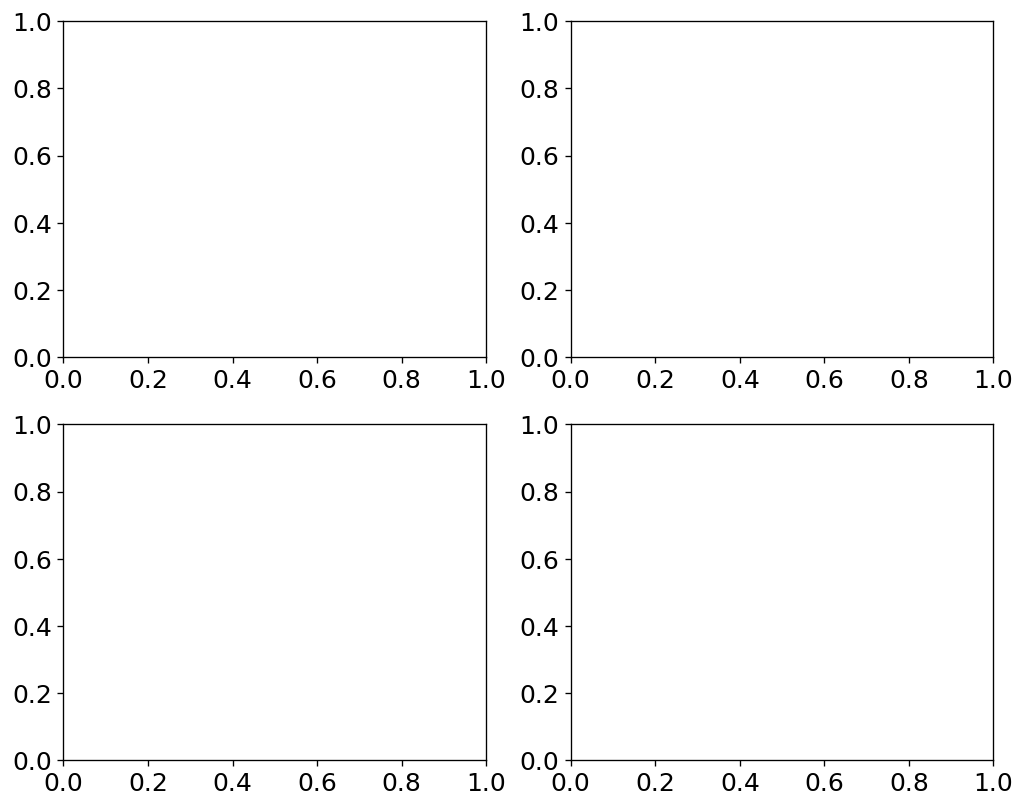

In [5]:
t_bkg, t_search = 1000, 0.5
fig, axs = plt.subplots(2, 2, dpi=120, figsize=(10, 8))
datas = [T2['barPinj'], T3['barPinj'], T2_['barPinj'], T3_['barPinj']]
labels = ['$I = 2$ w/o mass cut', '$I = 3$ w/o mass cut',
         '$I = 2$ w/ mass cut', '$I = 3$ w/ mass cut']
colors = ['cornflowerblue', 'darkorange', 'mediumseagreen', 'orchid']
for data, label, color, i, j in zip(datas, labels, colors,
                                    [0, 0, 1, 1], [0, 1, 0, 1]):
    epsilon = 1e-11
    counts, bins = binning.fit_and_binning(-np.log(1-data - epsilon))

    pl.FARvsEvents(counts, 1000, 0.5, color, axs[i, j], i, j, label)
plt.tight_layout()
#plt.xlim(0.998, 1.001)

H1L1


ValueError: too many values to unpack (expected 3)

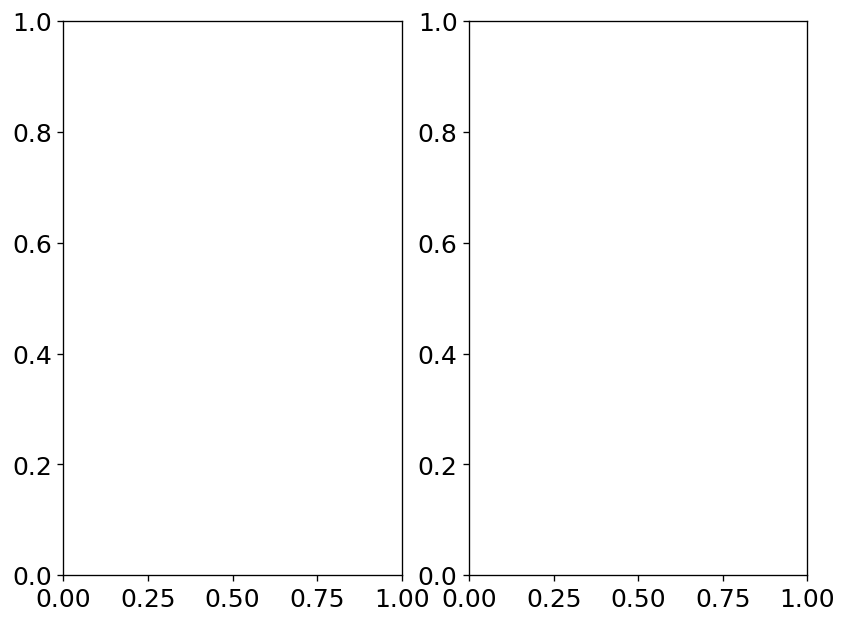

In [6]:
path_zero_lag = '/data/gravwav/lopezm/Projects/GlitchBank/computational-aspects-of-machine-learning-project-3/output_new/tw0.05/predictions/'
allcatalogs = pd.read_pickle('/data/gravwav/lopezm/Projects/GlitchBank/runs/known_catalogs.csv')
merge = Merge(path_store, timeslides_file)
d_arr = np.full(len(allcatalogs), np.nan)
allcatalogs['FAR_H1L1'], allcatalogs['FAR_H1V1'], allcatalogs['FAR_L1V1'], allcatalogs['FAR_H1L1V1'] = d_arr.copy(), d_arr.copy(), d_arr.copy(), d_arr.copy()
ifos = ['H1L1', 'H1V1', 'L1V1', 'H1L1V1']
colors = ['mediumorchid','cornflowerblue', 'hotpink', 'mediumseagreen']
dark_colors = ['indigo','navy', 'mediumvioletred', 'darkgreen']

fig, axs = plt.subplots(1, 2, dpi=120)
for ifo, color, dark_color in zip(ifos, colors, dark_colors):
    print(ifo)
    t_bkg, ts_data = merge.mergeTriggers(ifo.replace('1', "")) # FIXME
    binning = Binning()
    x, y, p = binning.fit_and_binning(data=ts_data['rank_stat_'+ifo], rank=3)
    
    # We generate the theoretical x and y
    x_fit = np.linspace(min(x), max(x), 100)
    y_fit = p(x_fit)

    # Variables: either counts, far or events
    y_obs, ylabel = binning.yVar(y, 'far', t_bkg, t_search)
    y_teo, _ = binning.yVar(y_fit, 'far', t_bkg, t_search)
    
    if len(ifo) == 4:
        ax = axs[0]
    else:
        ax = axs[1]
    ax.plot(x, y_obs, label=ifo, c=color)
    ax.set_yscale('log')
    ax.set_xlabel(r'$-\log{(1 - \bar{P}_{inj})}$')
    ax.set_ylabel(ylabel)
    ax.legend()
plt.tight_layout()
path_img = '/data/gravwav/lopezm/Projects/GlitchBank/computational-aspects-of-machine-learning-project-3/FAR/closedbox/' 
# Save the figure as PNG
plt.savefig(path_img +'background.png', dpi=300)  # Set dpi for high resolution

# Save the figure as PDF
plt.savefig(path_img +'background.pdf')

H1L1V1


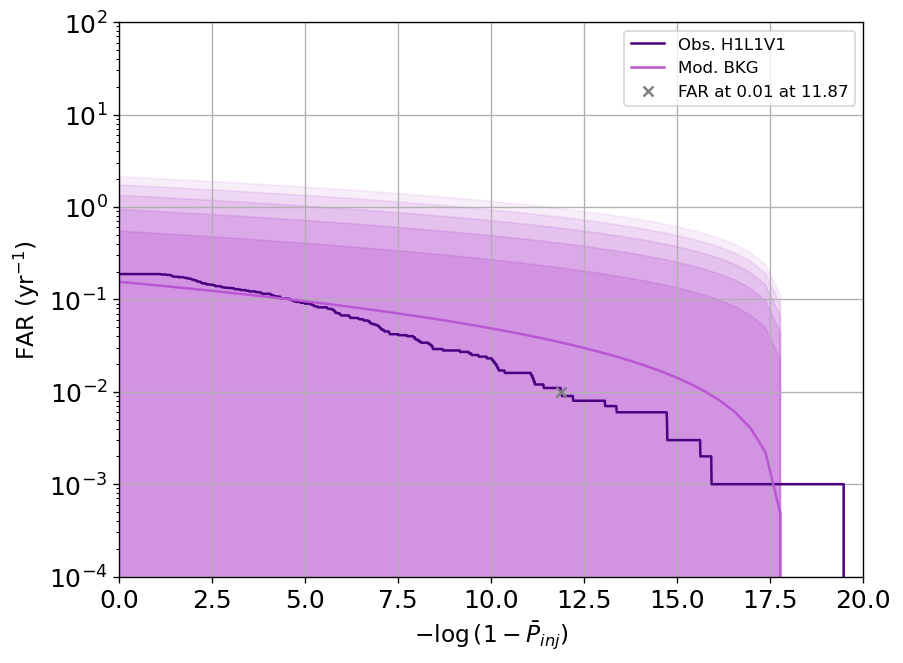

In [11]:
path_zero_lag = '/data/gravwav/lopezm/Projects/GlitchBank/computational-aspects-of-machine-learning-project-3/output_new/tw0.05/predictions/'
allcatalogs = pd.read_pickle('/data/gravwav/lopezm/Projects/GlitchBank/runs/known_catalogs.csv')
merge = Merge(path_store, timeslides_file)
d_arr = np.full(len(allcatalogs), np.nan)
allcatalogs['FAR_H1L1'], allcatalogs['FAR_H1V1'], allcatalogs['FAR_L1V1'], allcatalogs['FAR_H1L1V1'] = d_arr.copy(), d_arr.copy(), d_arr.copy(), d_arr.copy()
ifos = ['H1L1V1']
epsilon = 1e-20
sigma12, sigma22 = 3, 3 # sigma of mass1 for 2coinc, sigma of mass2 for 2coinc
sigma13, sigma23 = 9, 9 # sigma of mass1 for 3coinc, sigma of mass2 for 3coinc
colors = ['mediumorchid','cornflowerblue', 'hotpink', 'mediumseagreen']
dark_colors = ['indigo','navy', 'mediumvioletred', 'darkgreen']
binning = Binning()

for ifo, color, dark_color in zip(ifos, colors, dark_colors):
    print(ifo)
    t_bkg, ts_data = merge.mergeTriggers(ifo.replace('1', "")) # FIXME
    #zero_lag = prepareZeroLag(path_zero_lag, ifo.replace('1', ""))
    if len(ifo) == 4:
        #ts_data['barPinj'] = Measure.harmonic2coinc(ts_data['Pinj_'+ifo[:2].replace('1', "")], ts_data['Pinj_'+ifo[2:].replace('1', "")])
        #ts_data = prob2stat(ts_data, ifo, col='barPinj')
        ts_data = CoincMass(ts_data, [ifo[:2].replace('1', ""), ifo[2:].replace('1', "")], sigma12, sigma22).filterCoincMass()
        #zero_lag = CoincMass(zero_lag, [ifo[:2].replace('1', ""), ifo[2:].replace('1', "")], sigma12, sigma22).filterCoincMass()
    else:
        #ts_data['barPinj'] = Measure.harmonic3coinc(ts_data['Pinj_H1'], ts_data['Pinj_L1'], ts_data['Pinj_V1'])
        #ts_data = prob2stat(ts_data, ifo, col='barPinj')
        # Pass cut in mass1 and mass2
        ts_data = CoincMass(ts_data, ['H1', 'L1'], sigma13, sigma23).filterCoincMass()
        ts_data = CoincMass(ts_data, ['L1', 'V1'], sigma13, sigma23).filterCoincMass()

        #zero_lag = CoincMass(zero_lag, ['H1', 'L1'], sigma13, sigma23).filterCoincMass()
        #zero_lag = CoincMass(zero_lag, ['L1', 'V1'], sigma13, sigma23).filterCoincMass()
    
    
    x, y, p = binning.fit_and_binning(data=ts_data['rank_stat_'+ifo], rank=2)
    
    # We generate the theoretical x and y
    x_fit = np.linspace(min(x), max(x), 100)
    y_fit = p(x_fit)

    # Variables: either counts, far or events
    y_obs, ylabel = binning.yVar(y, 'far', t_bkg, t_search)
    y_obs_old, _ = binning.yVar(y, 'far', t_bkg, t_search)
    y_teo, _ = binning.yVar(y_fit, 'far', t_bkg, t_search)
    
    fig, axs = plt.subplots(dpi=120)
    threshold = pl.plotSigma(x, x_fit, y_obs, y_teo, color, dark_color,
              axs, ifo, ylabel, ylim=(1e-4, 100))

    plt.xlim(0, 20)
    plt.show()

    #tmp = zero_lag[(zero_lag['barPinj'] >= threshold)]
    #print('threshold', threshold, len(zero_lag))
    allcatalogs = returnFAR(allcatalogs, x, y_obs,ifo, far=0.01, offset=0.1)


In [10]:
offset, snr_veto = 0.1, 4.61
for ifos, delta_m, snr_veto in zip(I,[60, 80, 65, 60], [5, 5, 5, 5]):
    t_bkg, ts_data = merge.mergeTriggers(ifos.replace('1', "")) # FIXME
    print(ifos)
    pl.plotBKGvetoes(ts_data, ifos, t_bkg, t_search, snr_veto, delta_m)
    plt.savefig('./preopenbox/background_'+ifos+'.png', dpi=300)  # Set dpi for high resolution
    plt.savefig('./preopenbox/background_'+ifos+'.pdf')

H1L1


NameError: name 'ifo' is not defined

In [4]:
%%time
I = ['H1L1', 'H1V1', 'L1V1', 'H1L1V1']
offset, delta_m, snr_veto = 0.1,  12.7, 5
for ifos, delta_m, snr_veto in zip(I,[60, 80, 65, 60], [5, 5, 5, 5]):
    zero_lag_unvetoed = PrepareZeroLag(ifos)
    zero_lag = zero_lag_unvetoed.copy()
    allcatalogs = pd.read_pickle('/data/gravwav/lopezm/Projects/GlitchBank/runs/known_catalogs.csv')
    
    t_bkg, ts_data = merge.mergeTriggers(ifos.replace('1', "")) # FIXME
    pl.plotBKGvetoes(ts_data, ifos, t_bkg, t_search, snr_veto, delta_m)
    plt.savefig('./preopenbox/background_'+ifos+'.png', dpi=300)  # Set dpi for high resolution
    plt.savefig('./preopenbox/background_'+ifos+'.pdf')
    plt.close()
    # No vetoes
    foreground1, background1 = zero_lag.copy(), ts_data.copy() 
    
    x, y_obs, p_star, ylabel = Measure.getFARandThreshold(background1, ifos, t_bkg, t_search)
    cat = ut.getFARCatalog(foreground1, x, y_obs, allcatalogs, ifos, label='FAR_', offset=offset)
    pl.PlotGrapes(cat, ifos); print(p_star)
    plt.savefig('./preopenbox/grapes_no_vetoes_'+ifos+'.png', dpi=300)  # Set dpi for high resolution
    plt.savefig('./preopenbox/grapes_no_vetoes_'+ifos+'.pdf')
    plt.close()
    
    # SNR vetoes
    if len(ifos) == 4:
        zero_lag = SNRveto(snr_veto, zero_lag, [ifos[:2], ifos[2:]])
        ts_data = SNRveto(snr_veto, ts_data, [ifos[:2].replace('1', ""), ifos[2:].replace('1', "")])
    if len(ifos) == 6:
        zero_lag = SNRveto(snr_veto, zero_lag, ['H1', 'L1', 'V1'])
        ts_data = SNRveto(snr_veto, ts_data, ['H1', 'L1', 'V1'])
    foreground2, background2 = zero_lag.copy(), ts_data.copy() 
    print(len(foreground2), len(background2))
    
    x, y_obs, p_star, ylabel = Measure.getFARandThreshold(background2, ifos, t_bkg, t_search)
    cat = ut.getFARCatalog(foreground2, x, y_obs, allcatalogs, ifos, label='FAR_', offset=offset)
    pl.PlotGrapes(cat, ifos); print(p_star)
    plt.savefig('./preopenbox/grapes_SNR_vetoes_'+ifos+'.png', dpi=300)  # Set dpi for high resolution
    plt.savefig('./preopenbox/grapes_SNR_vetoes_'+ifos+'.pdf')
    plt.close()
    
    #SNR & Mass vetoes
    if len(ifos) == 4:
        zero_lag = CoincMass(zero_lag, [ifos[:2], ifos[2:]], delta_m, delta_m).filterCoincMass()
        ts_data = CoincMass(ts_data, [ifos[:2].replace('1', ""),
                                      ifos[2:].replace('1', "")], delta_m, delta_m).filterCoincMass()
    if len(ifos) == 6:
        zero_lag = CoincMass(zero_lag, ['H1', 'L1'], delta_m, delta_m).filterCoincMass()
        zero_lag = CoincMass(zero_lag, ['L1', 'V1'], delta_m, delta_m).filterCoincMass()
        ts_data = CoincMass(ts_data, ['H1', 'L1'], delta_m, delta_m).filterCoincMass()
        ts_data = CoincMass(ts_data, ['L1', 'V1'], delta_m, delta_m).filterCoincMass()
    foreground3, background3 = zero_lag.copy(), ts_data.copy() 
    print(len(foreground3), len(background3))
    
    x, y_obs, p_star, ylabel = Measure.getFARandThreshold(background3, ifos, t_bkg, t_search)
    cat = ut.getFARCatalog(foreground3, x, y_obs, allcatalogs, ifos, label='FAR_', offset=offset)
    pl.PlotGrapes(cat, ifos); print(p_star)
    plt.savefig('./preopenbox/grapes_SNR_mass_vetoes_'+ifos+'.png', dpi=300)  # Set dpi for high resolution
    plt.savefig('./preopenbox/grapes_SNR_mass_vetoes_'+ifos+'.pdf')
    plt.close()

    fars = []
    for i in range(len(zero_lag)):
        far, _ = Measure.stat2FAR(zero_lag['rank_stat_'+ifos].iloc[i], x, y_obs) #FIXME
        fars.append(far)
    zero_lag['FAR_'+ifos] = fars
    
    open_box = zero_lag.copy()
    if len(ifos) == 4:
        open_box['netSNR'] = np.sqrt(open_box['SNR_max_'+ifos[:2]]**2 + open_box['SNR_max_'+ifos[2:]]**2)
    if len(ifos) == 6:
        open_box['netSNR'] = np.sqrt(open_box['SNR_max_H1']**2 + open_box['SNR_max_L1']**2 + open_box['SNR_max_V1']**2)
    open_box = open_box[open_box['FAR_'+ifos] <=0.01]
    open_box = open_box.sort_values(by='netSNR', ascending=False)
    open_box.to_pickle('open_box_'+ifos)
    print(len(open_box))

42.421 GW190521 36.74
36.74
5574 178052
12.252 GW190521 34.22
34.22
5039 74471
32.54
0
28.023976023976022 GW190521 36.74
36.74
10150 275924
35.49
8966 126245
33.94
3
157.489 GW190521 36.74
36.74
11282 286731
36.050000000000004
9762 128905
35.64
5
0.088 GW190521 11.99
11.99
131 427
7.3
117 120
6.21
8
CPU times: user 2min 50s, sys: 2min 32s, total: 5min 23s
Wall time: 4min 41s


In [8]:
open_box.columns

!pwd

/data/gravwav/lopezm/Projects/GlitchBank/computational-aspects-of-machine-learning-project-3/FAR


In [14]:
for ifos in I:
    print(ifos)
    open_box = pd.read_pickle('open_box_'+ifos)
    if len(open_box) > 0:
        print(len(open_box))
        cluster_cols = [col for col in open_box.columns if all(sub in col for sub in ['Cluster time'])]
        snr_cols = [col for col in open_box.columns if all(sub in col for sub in ['SNR_max'])]
        cols = ['Cluster time_'+ifos[:2]] + snr_cols + ['Mass_1_max_'+ifos[:2], 'Mass_2_max_'+ifos[:2], 'netSNR','rank_stat_'+ifos, 'FAR_'+ifos]

        print(open_box[cols].to_string(index=False, header=True, col_space=20, justify='center', line_width=200))

H1L1
H1V1
3
   Cluster time_H1        SNR_max_H1           SNR_max_V1          Mass_1_max_H1        Mass_2_max_H1           netSNR           rank_stat_H1V1          FAR_H1V1      
   1258437064.515           5.074                5.745               112.966               11.677               7.665                46.052               0.001        
   1256920223.274           5.261                5.103                84.008                9.215               7.330                35.127               0.008        
   1262323985.971           5.016                5.281                58.353               18.237               7.284                46.052               0.001        
L1V1
5
   Cluster time_L1        SNR_max_L1           SNR_max_V1          Mass_1_max_L1        Mass_2_max_L1           netSNR           rank_stat_L1V1          FAR_L1V1      
   1238177476.053           6.168                5.567                73.736               14.613               8.309                46.052  

In [7]:
open_box
for o in range(len(open_box)):
    time_o = open_box['Cluster time_H1'].iloc[o]
    if len(ut.searchTime(allcatalogs, time_o, 'GPS')):
        display(ut.searchTime(allcatalogs, time_o, 'GPS'))

times = [1241614563.77, 1244555287.93, 1243931925.99,  1265231787.68, 1246380410.88,  1240156946.51,
1245830226.79,  1240929987.65,  1249397698.41,  1243982381.42,  1242345085.55, 1240386545.71,
 1239433520.84,  1264809513.19,  1249458753.03,  1238476845.84]

for o in range(len(open_box)):
    time_o = open_box['Cluster time_H1'].iloc[0]
    if len(np.where(np.abs(time_o - times) < 0.5)[0]) > 0:
        print(time_o)
    

,Name,GPS,SNR,Chirp mass,Mass1,Mass2,Ifos_H1,SNR_H1,Chirp mass_H1,Probability_H1,Cluster time_H1,Num triggers,Ifos_L1,SNR_L1,Chirp mass_L1,Probability_L1,Cluster time_L1,Num triggers_L1,Ifos_V1,SNR_V1,Chirp mass_V1,Probability_V1,Cluster time_V1,Num triggers_V1,Ifos_H1L1,SNR_H1L1,Chirp mass_H1L1,Probability_H1L1,Cluster time_H1L1,Num triggers_H1L1,Ifos_H1V1,SNR_H1V1,Chirp mass_H1V1,Probability_H1V1,Cluster time_H1V1,Num triggers_H1V1,Ifos_L1V1,SNR_L1V1,Chirp mass_L1V1,Probability_L1V1,Cluster time_L1V1,Num triggers_L1V1,inHUll,Catalog,RS_H1L1,RS_H1V1,RS_L1V1,RS_H1L1V1,FAR_H1L1V1
74,GW200224_222234,1266618172.400,20.000,31.100,40.000,32.500,H1,20.000,31.100,1.000,1266618172.405,161,L1,20.000,31.100,1.000,1266618172.402,164,V1,20.000,31.100,1.000,1266618172.378,89,H1L1,20.000,31.100,1.000,"[1266618172.4053335, 1266618172.402307]","[161.0, 164.0]",H1V1,20.000,31.100,1.000,"[1266618172.4053335, 1266618172.3780255]","[161.0, 89.0]",L1V1,20.000,31.100,1.000,"[1266618172.402307, 1266618172.3780255]","[164.0, 89.0]",o,GWOSC,16.576,15.631,16.122,16.036,0.001
107,GW200224_220236,1266618172.388,18.065,44.294,63.602,41.091,H1,18.065,44.294,1.000,1266618172.405,161,L1,18.065,44.294,1.000,1266618172.402,164,V1,18.065,44.294,1.000,1266618172.378,89,H1L1,18.065,44.294,1.000,"[1266618172.4053335, 1266618172.402307]","[161.0, 164.0]",H1V1,18.065,44.294,1.000,"[1266618172.4053335, 1266618172.3780255]","[161.0, 89.0]",L1V1,18.065,44.294,1.000,"[1266618172.402307, 1266618172.3780255]","[164.0, 89.0]",o,Princeton,16.576,15.631,16.122,16.036,0.001


In [ ]:
!pip inst

In [8]:
import pandas as pd
from pptx import Presentation
from pptx.util import Inches

# Sample DataFrame
data = {
    'Column 1': [1, 2, 3],
    'Column 2': ['A', 'B', 'C'],
    'Column 3': [4.5, 5.5, 6.5]
}
df = pd.DataFrame(data)

# Create a PowerPoint presentation object
prs = Presentation()

# Add a slide with a title and content layout
slide_layout = prs.slide_layouts[5]  # Choosing a layout with a title and content
slide = prs.slides.add_slide(slide_layout)
title = slide.shapes.title
title.text = "DataFrame to Table"

# Define the table size and position
x, y, cx, cy = Inches(1), Inches(1), Inches(6), Inches(2)

# Add a table to the slide
rows, cols = df.shape
table = slide.shapes.add_table(rows+1, cols, x, y, cx, cy).table

# Set the column names
for col_idx, col_name in enumerate(df.columns):
    table.cell(0, col_idx).text = col_name

# Fill the table with data
for row_idx in range(rows):
    for col_idx in range(cols):
        table.cell(row_idx+1, col_idx).text = str(df.iloc[row_idx, col_idx])

# Save the presentation
prs.save('DataFrame_to_Table.pptx')


ModuleNotFoundError: No module named 'pptx'

In [401]:
open_box[['Cluster time_H1', 'Cluster time_L1', 'Cluster time_V1', 'SNR_max_H1', 'SNR_max_L1', 'SNR_max_V1', 'netSNR', 'rank_stat_H1L1V1', 'FAR_H1L1V1']]

,Cluster time_H1,Cluster time_L1,Cluster time_V1,SNR_max_H1,SNR_max_L1,SNR_max_V1,netSNR,rank_stat_H1L1V1,FAR_H1L1V1
8324,1266618172.405,1266618172.402,1266618172.378,12.697,13.093,6.045,19.214,16.036,0.001
2232,1244498266.036,1244498266.031,1244498266.024,5.062,6.000,5.216,9.425,9.011,0.004
8634,1267565774.333,1267565774.338,1267565774.307,6.134,5.040,4.859,9.308,16.790,0.001
3554,1249495257.187,1249495257.188,1249495257.198,5.557,5.563,4.961,9.298,23.245,0.001
8680,1267656427.230,1267656427.223,1267656427.254,4.745,4.866,6.253,9.235,11.534,0.001
282,1238924167.813,1238924167.824,1238924167.842,5.758,4.822,5.198,9.134,8.216,0.005
1639,1242971649.580,1242971649.580,1242971649.592,5.623,4.767,5.213,9.029,8.543,0.004
2782,1246400250.272,1246400250.268,1246400250.294,4.938,4.900,5.553,8.901,8.185,0.005
3848,1250567117.209,1250567117.221,1250567117.214,4.991,5.323,5.080,8.891,8.250,0.005
3580,1249547253.938,1249547253.941,1249547253.915,5.256,5.279,4.815,8.870,9.596,0.003


In [356]:
cond1 = (np.abs(open_box['Cluster time_H1'] - open_box['Cluster time_L1']) <=0.005)
cond2 = (np.abs(open_box['Cluster time_H1'] - open_box['Cluster time_V1']) <=0.005)
cond3 = (np.abs(open_box['Cluster time_L1'] - open_box['Cluster time_V1']) <=0.005)
open_box[cond1 & cond2 & cond3]


,SNR_H1,Chisq_H1,Mass_1_H1,Mass_2_H1,Spin1z_H1,Spin2z_H1,Prob0_H1,Prob1_H1,Prob2_H1,Prob3_H1,Prob4_H1,Prob5_H1,Prob6_H1,Num triggers_H1,Cluster ID_H1,Cluster time_H1,SNR_L1,Chisq_L1,Mass_1_L1,Mass_2_L1,Spin1z_L1,Spin2z_L1,Prob0_L1,Prob1_L1,Prob2_L1,Prob3_L1,Prob4_L1,Prob5_L1,Prob6_L1,Num triggers_L1,Cluster ID_L1,Cluster time_L1,SNR_V1,Chisq_V1,Mass_1_V1,Mass_2_V1,Spin1z_V1,Spin2z_V1,Prob0_V1,Prob1_V1,Prob2_V1,Prob3_V1,Prob4_V1,Prob5_V1,Num triggers_V1,Cluster ID_V1,Cluster time_V1,Pinj_H1,rank_stat_H1,SNR_max_H1,Mass_1_max_H1,Mass_2_max_H1,Pinj_L1,rank_stat_L1,SNR_max_L1,Mass_1_max_L1,Mass_2_max_L1,Pinj_V1,rank_stat_V1,SNR_max_V1,Mass_1_max_V1,Mass_2_max_V1,barPinj,rank_stat_H1L1V1,FAR_H1L1V1,netSNR
5804,4.494,1.007,66.995,10.085,-0.456,0.037,13.515,-25.609,-111.454,3.691,-91.571,-1.400,-82.417,27.000,28256.000,1259111268.232,4.811,1.624,67.298,10.087,-0.454,0.051,16.606,-3.300,-45.481,-20.945,6.085,-104.476,-0.373,27.000,33441.000,1259111268.236,4.436,1.114,59.446,10.001,-0.473,-0.036,4.282,-20.940,-92.828,-11.681,-40.395,-18.999,50.000,34573.000,1259111268.231,1.000,9.818,4.828,59.516,8.554,1.000,10.519,5.243,54.637,5.477,1.000,15.963,4.882,54.684,6.204,1.000,10.512,0.002,8.639
7289,4.574,0.930,49.393,13.549,0.590,-0.190,20.378,0.178,-91.885,2.552,-289.085,10.337,-135.667,16.000,34210.000,1263354902.737,4.463,0.803,49.963,13.600,0.609,-0.168,21.895,-29.118,-82.635,-11.622,-63.829,-33.721,-5.794,16.000,37303.000,1263354902.733,4.314,1.313,50.127,13.523,0.601,-0.165,23.932,-0.397,-162.259,-12.215,-204.544,-3.402,16.000,34953.000,1263354902.737,1.000,10.040,5.125,43.858,9.149,1.000,27.686,4.983,36.279,13.870,1.000,24.280,4.738,43.858,9.149,1.000,11.139,0.001,8.575
5729,4.344,0.966,46.637,9.497,-0.082,-0.343,9.765,-6.948,-100.933,-0.815,-187.394,-2.694,-48.229,17.000,4915.000,1258842311.701,4.185,1.030,46.709,9.377,-0.090,-0.328,21.914,-5.267,-84.982,-16.739,-18.495,-17.714,-3.604,17.000,5269.000,1258842311.701,4.516,1.105,46.693,9.440,-0.084,-0.341,14.576,-17.134,-126.311,-3.326,-99.399,-36.764,17.000,4404.000,1258842311.704,1.000,10.436,4.681,42.505,10.803,1.000,25.345,4.620,41.953,8.227,1.000,17.902,4.942,46.847,10.424,1.000,11.534,0.001,8.227


In [162]:
for ifo in ['H1', 'L1', 'V1']:
   zero_lag = LogitToStat(zero_lag, 1, ['Prob', ifo], 'Pinj_'+ifo)
   zero_lag = Measure.prob2stat(zero_lag, ifo, col='Pinj_'+ifo)
   zero_lag = getMaxValues(ifo, '/data/gravwav/lopezm/Projects/GlitchBank/time_slides/', zero_lag)
zero_lag['barPinj'] = Measure.harmonic3coinc(zero_lag['Pinj_H1'], zero_lag['Pinj_L1'], zero_lag['Pinj_V1'], epsilon=1e-20)
zero_lag = Measure.prob2stat(zero_lag, 'H1L1V1', col='barPinj')
tmp = zero_lag[(zero_lag['Cluster time_V1'] >= 1251286995.561855 - 1) & (zero_lag['Cluster time_V1'] <= 1251286995.561855 + 1)]

,SNR_H1,Chisq_H1,Mass_1_H1,Mass_2_H1,Spin1z_H1,Spin2z_H1,Prob0_H1,Prob1_H1,Prob2_H1,Prob3_H1,Prob4_H1,Prob5_H1,Prob6_H1,Num triggers_H1,Cluster ID_H1,Cluster time_H1,SNR_L1,Chisq_L1,Mass_1_L1,Mass_2_L1,Spin1z_L1,Spin2z_L1,Prob0_L1,Prob1_L1,Prob2_L1,Prob3_L1,Prob4_L1,Prob5_L1,Prob6_L1,Num triggers_L1,Cluster ID_L1,Cluster time_L1,SNR_V1,Chisq_V1,Mass_1_V1,Mass_2_V1,Spin1z_V1,Spin2z_V1,Prob0_V1,Prob1_V1,Prob2_V1,Prob3_V1,Prob4_V1,Prob5_V1,Num triggers_V1,Cluster ID_V1,Cluster time_V1,Pinj_H1,rank_stat_H1,SNR_max_H1,Mass_1_max_H1,Mass_2_max_H1,Pinj_L1,rank_stat_L1,SNR_max_L1,Mass_1_max_L1,Mass_2_max_L1,Pinj_V1,rank_stat_V1,SNR_max_V1,Mass_1_max_V1,Mass_2_max_V1,barPinj,rank_stat_H1L1V1
209252,4.849,0.916,38.674,19.173,-0.442,-0.518,8.974,-16.597,-136.547,-33.058,-108.499,-10.668,-145.010,16.000,54163.000,1251286995.522,4.688,1.125,42.637,15.306,0.005,-0.243,12.904,-0.560,-62.935,-16.407,-86.678,-41.310,-11.435,24.000,58088.000,1251286995.553,4.946,0.802,46.809,10.634,0.746,0.195,28.721,-59.650,-160.351,18.919,-134.636,-4.130,12.000,55335.000,1251286995.562,1.000,19.639,5.342,32.333,17.780,1.000,13.464,5.149,41.424,9.553,1.000,9.802,5.279,40.320,11.402,1.000,10.875


In [170]:
tmp = zero_lag[(zero_lag['Cluster time_V1'] >= 1251286995.561855 - 1) & (zero_lag['Cluster time_V1'] <= 1251286995.561855 + 1)]
tmp['Mass_1_max_H1'] - tmp['Mass_1_max_V1'], tmp['Mass_1_max_H1'] - tmp['Mass_1_max_L1']


(209252   -7.988
 dtype: float64,
 209252   -9.092
 dtype: float64)

In [19]:
#plt.hist(allcatalogs['FAR_H1L1V1'])
ld = []
for ifo in ifos:
    for j in range(len(allcatalogs)):
        if not np.isnan(allcatalogs['Num triggers_'+ifo].iloc[j]).all():
            if 1 not in allcatalogs['Num triggers_'+ifo].iloc[j]:
                if allcatalogs['FAR_'+ifo].iloc[j] <= 0.1:
                    ld.append(j)
ld = np.unique(ld)
little_dogs = allcatalogs.loc[ld]
len(little_dogs['GPS'])

12

In [20]:
little_dogs[['Name', 'Catalog', 'FAR_H1L1', 'FAR_H1V1', 'FAR_L1V1',	'FAR_H1L1V1']]

,Name,Catalog,FAR_H1L1,FAR_H1V1,FAR_L1V1,FAR_H1L1V1
11,GW190513_205428,GWOSC,1.181,0.943,1.946,0.001
15,GW190521,GWOSC,11.431,3.254,24.153,0.066
20,GW190630_185205,GWOSC,NaN,NaN,0.001,NaN
28,GW190727_060333,GWOSC,3.729,4.804,13.375,0.017
51,GW191127_050227,GWOSC,14.010,15.197,3.602,0.091
66,GW200208_222617,GWOSC,4.959,4.609,9.994,0.017
74,GW200224_222234,GWOSC,1.486,1.537,5.718,0.001
83,200106_134123,Nitz,0.001,0.311,1.737,0.001
94,GW190513_200230,Princeton,1.181,0.943,1.946,0.001
96,GW190727_060235,Princeton,3.729,4.804,13.375,0.017


In [21]:
# Check if little dogs are inside
w = 1

for ifo in ifos:
    time_bkg, ts_data = merge.mergeTriggers(ifo.replace('1', "")) # FIXME
    print(ifo)
    for t in allcatalogs['GPS']:

        if ifo == 4:
            i1, i2 = ifo[:2], ifo[2:]
            cond1 = ((ts_data['Cluster_time_old_'+i1.replace('1', "")] >= t - w) & (ts_data['Cluster_time_old_'+i1.replace('1', "")] <= t + w))
            cond2 = ((ts_data['Cluster_time_old_'+i2.replace('1', "")] >= t - w) & (ts_data['Cluster_time_old_'+i2.replace('1', "")] <= t + w))
            tmp = len(ts_data[cond1 | cond2])
            if len(tmp) > 0:
                print(ifo, t, tmp)
        if ifo == 6:
            i1, i2, i3 = 'H1', 'L1', 'V1'
            cond1 = ((ts_data['Cluster_time_old_'+i1.replace('1', "")] >= t - w) & (ts_data['Cluster_time_old_'+i1.replace('1', "")] <= t + w))
            cond2 = ((ts_data['Cluster_time_old_'+i2.replace('1', "")] >= t - w) & (ts_data['Cluster_time_old_'+i2.replace('1', "")] <= t + w))
            cond3 = ((ts_data['Cluster_time_old_'+i3.replace('1', "")] >= t - w) & (ts_data['Cluster_time_old_'+i3.replace('1', "")] <= t + w))
            tmp = len(ts_data[cond1 | cond2 | cond3])
            if len(tmp) > 0:
                print(ifo, t, tmp)
        
#len(ts_data)

H1L1
H1V1
L1V1
H1L1V1


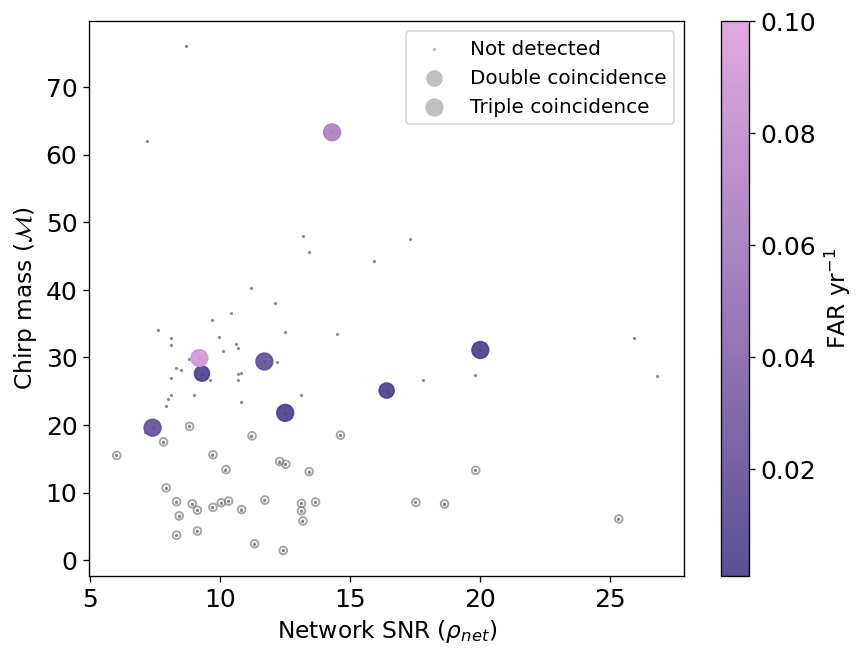

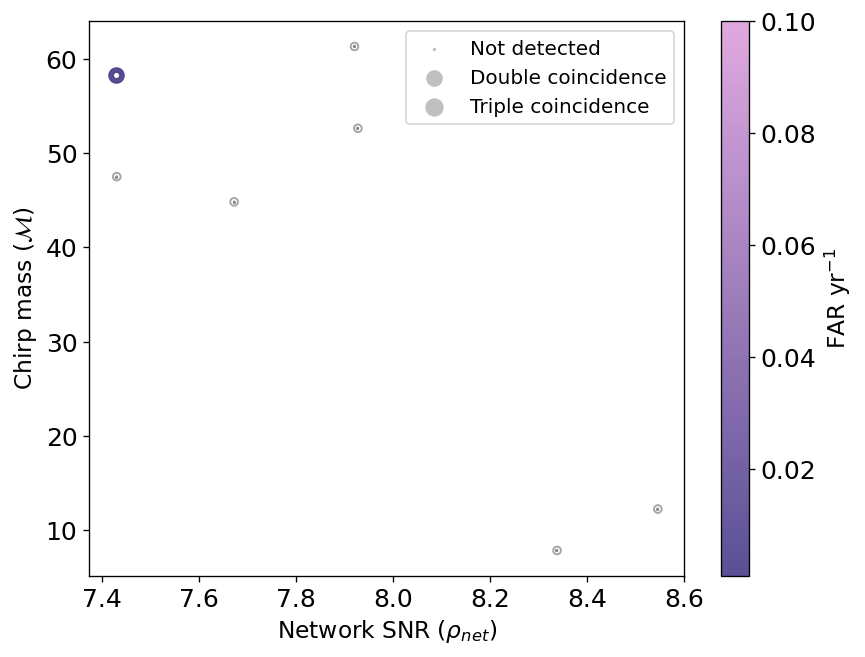

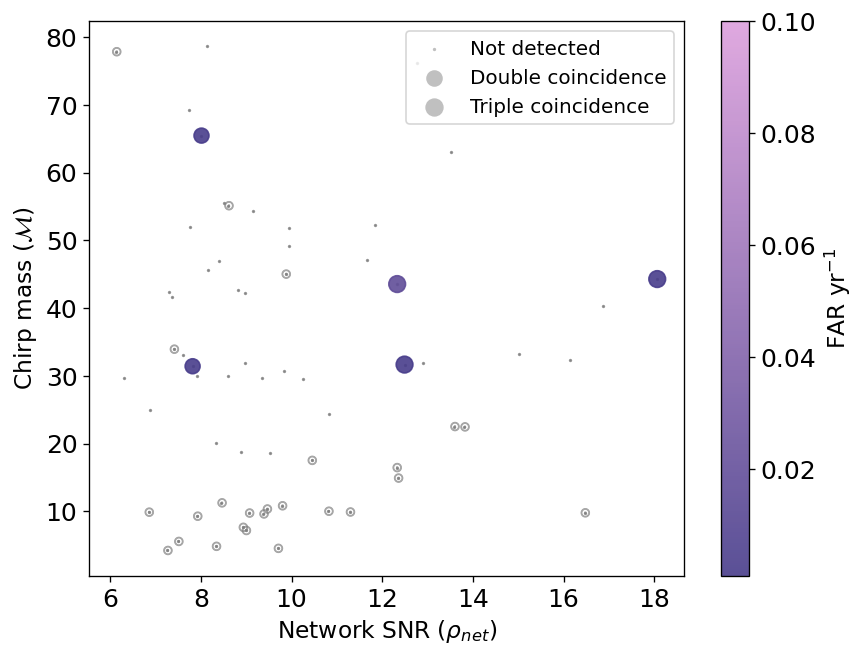

In [106]:
from matplotlib.ticker import StrMethodFormatter
for cat in ['GWOSC', 'Nitz', 'Princeton']:
    df1 = allcatalogs[allcatalogs['Catalog'] == cat]
    df2 = little_dogs[little_dogs['Catalog'] == cat]
    dh1 = df1[df1['inHUll'] == 'p']
    dh2 = df2[df2['inHUll'] == 'p']
    sel_cols = df2[['FAR_H1L1', 'FAR_H1V1', 'FAR_L1V1', 'FAR_H1L1V1']]#[selected_columns].min(axis=1)
    min_values = np.round(sel_cols.min(axis=1),3)
    min_columns = sel_cols.idxmin(axis=1)*10
    
    cmap = LinearSegmentedColormap.from_list(name='test', colors=['darkslateblue', 'plum'])
    fig = plt.figure(dpi=120)
    plt.scatter(df1['SNR'], df1['Chirp mass'], c='grey', s=1,alpha=0.8)
    plt.scatter(dh1['SNR'], dh1['Chirp mass'], s=35, color='grey',alpha=0.8, lw=0.5, marker=r'$\odot$', facecolors='none', edgecolors='grey')
  
    plt.scatter(dh2['SNR'], dh2['Chirp mass'],  s=80/20, marker='o', color='white', zorder=10)
    plt.scatter(df2['SNR'], df2['Chirp mass'], c=min_values, s=min_columns.str.len(), cmap=cmap, alpha=0.9)

    cbar = plt.colorbar(label =r'FAR yr$^{-1}$')

    cbar.ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.3f}'))
    plt.clim(0.001, 0.1)
    g1 = plt.scatter([],[], s=1, marker='o', color='silver')
    g3 = plt.scatter([],[], s=8*10, marker='o', color='silver')
    g4 = plt.scatter([],[], s=10*10, marker='o', color='silver')
    
    plt.legend((g1, g3, g4),
           ('Not detected', 'Double coincidence', 'Triple coincidence'),
           scatterpoints=1, fontsize=12,
           ncol=1, loc='upper right')
    plt.xlabel(r'Network SNR ($\rho_{net}$)'), plt.ylabel(r'Chirp mass $(\mathcal{M}$)')


### Injection recovery

Data is in `/data/gravwav/lopezm/Projects/GlitchBank/runs/injections/`

In [23]:
pd.read_pickle('/data/gravwav/lopezm/Projects/GlitchBank/runs/injections/imbh_injections_chunk10.csv').columns

Index(['injSNRH1', 'injSNRL1', 'injSNRV1', 'GPS', 'GPS ns', 'Mass1', 'Mass2',
       'Cluster ID', 'Distance', 'Cluster time', 'InsideH1', 'InsideL1',
       'InsideV1', 'InsideH1L1', 'InsideH1V1', 'InsideL1V1', 'InsideH1L1V1',
       'feature_H1', 'Class_H1', 'Num triggers_H1', 'Cluster ID_H1',
       'Cluster time_H1', 'MaxMass_1_H1', 'MaxMass_2_H1', 'feature_L1',
       'Class_L1', 'Num triggers_L1', 'Cluster ID_L1', 'Cluster time_L1',
       'MaxMass_1_L1', 'MaxMass_2_L1', 'feature_V1', 'Class_V1',
       'Num triggers_V1', 'Cluster ID_V1', 'Cluster time_V1', 'MaxMass_1_V1',
       'MaxMass_2_V1'],
      dtype='object')

In [ ]:
path_inj = '/data/gravwav/lopezm/Projects/GlitchBank/runs/injections/'

In [ ]:
for ifo in ['H1', 'L1', 'V1', 'H1L1', 'H1V1', 'L1V1', 'H1L1V1']:
    tmp = pd.read_csv(path_inj + 'inj'+ifo+'.csv')
    print(ifo, len(tmp))


In [ ]:
tmp['barPinj'] = harmonic3coinc(tmp['ProbInj_V1'], tmp['ProbInj_V1'], tmp['ProbInj_V1'])

In [ ]:
# Boolean indexing to filter values within the range
stats = [col for col in allcatalogs.columns if 'Stat_rank' in col]
for i in range(len(allcatalogs)):
    tmp = allcatalogs.iloc[i]
    t_event =  tmp['Cluster time_H1']
    filtered_values = T3[(T3['Cluster_time_H1'] >= t_event - 0.1) & (T3['Cluster_time_H1'] <= t_event + 0.1)]
    if len(filtered_values) > 0:

        print(tmp[stats])
        print( filtered_values.index)

In [2]:
tproper = ut.CountProperTime()

In [3]:
tproper.head(4)

,dH1s,dL1s,dV1s,dL1s_fix,H,L,V,HL_nV,HV_nL,LV_nH,HLV
0,0.000,3.000,9.000,0.000,0.674,0.696,0.989,0.000,0.000,0.134,0.562
1,0.000,6.000,12.000,0.000,0.674,0.696,0.989,0.000,0.000,0.134,0.562
2,0.000,9.000,15.000,0.000,0.674,0.696,0.989,0.000,0.000,0.134,0.562
3,0.000,12.000,18.000,0.000,0.674,0.696,0.989,0.000,0.000,0.134,0.562


In [4]:
tproper.to_csv('timeslides_proper.csv')

In [5]:
tproper[0:2000].sum()

dH1s             0.000
dL1s       6003000.000
dV1s       6015000.000
dL1s_fix         0.000
H             1347.553
L             1391.845
V             1977.710
HL_nV            0.234
HV_nL            0.212
LV_nH          237.404
HLV           1114.636
dtype: float64